In [4]:
import json
import numpy as np
import pandas as pd

train_split_df = pd.read_csv("../datasets/processed/train_split.csv")  
val_split_df = pd.read_csv("../datasets/processed/val_split.csv")
test_df = pd.read_csv("../datasets/processed/test.csv")

with open("../artifacts/vocab.json", encoding="utf-8") as f:
    vocab = json.load(f)

with open("../artifacts/max_len.json", encoding="utf-8") as f:
    max_len_config = json.load(f)

print("Vocab size:", len(vocab))
print("max_len config:", max_len_config)
print("train_split:", train_split_df.shape, " val_split:", val_split_df.shape, " test:", test_df.shape)

Vocab size: 96
max_len config: {'max_len': 250, 'truncating_strategy': 'head_tail', 'head_len': 125, 'tail_len': 125, 'padding': 'post', 'pad_token_index': 0}
train_split: (19779, 2)  val_split: (4945, 2)  test: (6181, 2)


In [5]:
PAD_IDX = vocab["<PAD>"]
UNK_IDX = vocab["<UNK>"]
MAX_LEN = max_len_config["max_len"]
HEAD_LEN = max_len_config["head_len"]
TAIL_LEN = max_len_config["tail_len"]

def query_to_sequence(query: str) -> np.ndarray:
    q = str(query)
    length = len(q)

    if length > MAX_LEN:
        # head+tail truncation: giữ HEAD_LEN ký tự đầu + TAIL_LEN ký tự cuối
        chars = q[:HEAD_LEN] + q[length - TAIL_LEN:]
    else:
        chars = q

    # index hóa theo vocab, ký tự lạ -> <UNK>
    indices = [vocab.get(c, UNK_IDX) for c in chars]

    # post-padding bằng <PAD> nếu ngắn hơn MAX_LEN
    if len(indices) < MAX_LEN:
        indices = indices + [PAD_IDX] * (MAX_LEN - len(indices))

    return np.array(indices, dtype=np.int32)

In [ ]:
# Test 1: câu ngắn — kiểm tra chèn padding
short_query = "SELECT * FROM users"
seq1 = query_to_sequence(short_query)
print("Test 1 - câu ngắn:")
print("  độ dài gốc:", len(short_query))
print("  10 index đầu:", seq1[:10])
print("  10 index cuối:", seq1[-10:])  # phải toàn số 0 (<PAD>)
print("  tổng số PAD:", (seq1 == PAD_IDX).sum(), "kỳ vọng:", MAX_LEN - len(short_query))
print()

# Test 2: câu dài >250 ký tự, có dấu hiệu riêng biệt ở đầu và cuối — kiểm tra head+tail truncation
long_query = "A" * 100 + "MIDDLE_PART_SHOULD_BE_CUT" * 10 + "Z" * 100
print("Test 2 - câu dài (độ dài gốc:", len(long_query), "):")
seq2 = query_to_sequence(long_query)
print("  độ dài sequence:", len(seq2), "kỳ vọng:", MAX_LEN)
# ký tự 'A' có index cố định trong vocab, kiểm tra 125 vị trí đầu toàn là index của 'A'
a_idx = vocab["A"]
z_idx = vocab["Z"]
print("  125 vị trí đầu toàn 'A'?", (seq2[:125] == a_idx).all())
print("  125 vị trí cuối toàn 'Z'?", (seq2[125:250] == z_idx).all())
print()

# Test 3: ký tự lạ không có trong vocab — kiểm tra map sang <UNK>
weird_query = "SELECT 트리 FROM test"  #phát hiện ký tự tiếng Hàn ở tuần 3
seq3 = query_to_sequence(weird_query)
print("Test 3 - ký tự lạ:")
print("  có xuất hiện <UNK> trong sequence?", (seq3 == UNK_IDX).any())
print("  số lần <UNK> xuất hiện:", (seq3 == UNK_IDX).sum())

Test 1 - câu ngắn:
  độ dài gốc: 19
  10 index đầu: [53 39 46 39 37 54  2 12  2 40]
  10 index cuối: [0 0 0 0 0 0 0 0 0 0]
  tổng số PAD: 231 kỳ vọng: 231

Test 2 - câu dài (độ dài gốc: 450 ):
  độ dài sequence: 250 kỳ vọng: 250
  125 vị trí đầu toàn 'A'? False
  125 vị trí cuối toàn 'Z'? False

Test 3 - ký tự lạ:
  có xuất hiện <UNK> trong sequence? True
  số lần <UNK> xuất hiện: 2


In [ ]:
# Test 2b: test lại câu dài, đảm bảo phần đầu/cuối riêng biệt dài hơn 125 ký tự
long_query_v2 = "A" * 150 + "MIDDLE_PART_SHOULD_BE_CUT" * 10 + "Z" * 150
seq2b = query_to_sequence(long_query_v2)

a_idx = vocab["A"]
z_idx = vocab["Z"]

print("Test 2b - câu dài (độ dài gốc:", len(long_query_v2), "):")
print("  độ dài sequence:", len(seq2b), "kỳ vọng:", MAX_LEN)
print("  125 vị trí đầu toàn 'A'?", (seq2b[:125] == a_idx).all(), "kỳ vọng: True")
print("  125 vị trí cuối toàn 'Z'?", (seq2b[125:250] == z_idx).all(), "kỳ vọng: True")

print("  ký tự tại vị trí 124 (cuối head) là 'A'?", seq2b[124] == a_idx, "kỳ vọng: True")
print("  ký tự tại vị trí 125 (đầu tail) là 'Z'?", seq2b[125] == z_idx, "kỳ vọng: True")

Test 2b - câu dài (độ dài gốc: 550 ):
  độ dài sequence: 250 kỳ vọng: 250
  125 vị trí đầu toàn 'A'? True kỳ vọng: True
  125 vị trí cuối toàn 'Z'? True kỳ vọng: True
  ký tự tại vị trí 124 (cuối head) là 'A'? True kỳ vọng: True
  ký tự tại vị trí 125 (đầu tail) là 'Z'? True kỳ vọng: True


In [8]:
# Ap dụng lên toàn bộ train_split, val_split, test và lưu lại

train_sequences = np.stack(train_split_df["Query"].apply(query_to_sequence).values)
val_sequences = np.stack(val_split_df["Query"].apply(query_to_sequence).values)
test_sequences = np.stack(test_df["Query"].apply(query_to_sequence).values)

print("train_sequences shape:", train_sequences.shape, "kỳ vọng:", (len(train_split_df), 250))
print("val_sequences shape:", val_sequences.shape, "kỳ vọng:", (len(val_split_df), 250))
print("test_sequences shape:", test_sequences.shape, "kỳ vọng:", (len(test_df), 250))

import os
os.makedirs("datasets/processed", exist_ok=True)

np.save("../datasets/processed/train_split_sequences.npy", train_sequences)
np.save("../datasets/processed/val_split_sequences.npy", val_sequences)
np.save("../datasets/processed/test_sequences.npy", test_sequences)

print("Đã lưu 3 file .npy vào datasets/processed/")

train_sequences shape: (19779, 250) kỳ vọng: (19779, 250)
val_sequences shape: (4945, 250) kỳ vọng: (4945, 250)
test_sequences shape: (6181, 250) kỳ vọng: (6181, 250)
Đã lưu 3 file .npy vào datasets/processed/


In [10]:
from tensorflow.keras import layers, models, callbacks, optimizers

VOCAB_SIZE = len(vocab)
print("VOCAB_SIZE:", VOCAB_SIZE)

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.LSTM(units=64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

model.summary()

VOCAB_SIZE: 96


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 64)        │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,233 (153.25 KB)

 Trainable params: 39,233 (153.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

# Cột "Label", giá trị 0(hợp lệ)/ 1(SQLi)
y_train = train_split_df["Label"].values
y_val = val_split_df["Label"].values

print("Phân bố nhãn train:", pd.Series(y_train).value_counts(normalize=True).to_dict())
print("Phân bố nhãn val:", pd.Series(y_val).value_counts(normalize=True).to_dict())

start = time.time()
history_trial = model.fit(
    train_sequences, y_train,
    validation_data=(val_sequences, y_val),
    epochs=3,
    batch_size=64,
    verbose=1
)
elapsed = time.time() - start

print(f"\nThời gian chạy 3 epoch: {elapsed:.1f} giây (~{elapsed/60:.2f} phút)")
print(f"Ước tính thời gian cho tối đa 30 epoch: ~{elapsed/3*30/60:.2f} phút")

Phân bố nhãn train: {0: 0.6318317407351232, 1: 0.3681682592648769}
Phân bố nhãn val: {0: 0.6319514661274014, 1: 0.36804853387259856}
Epoch 1/3
310/310 ━━━━━━━━━━━━━━━━━━━━ 53s 159ms/step - accuracy: 0.6732 - loss: 0.6211 - precision: 0.9305 - recall: 0.1214 - val_accuracy: 0.6760 - val_loss: 0.6129 - val_precision: 0.9739 - val_recall: 0.1231
Epoch 2/3
310/310 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.7599 - loss: 0.4896 - precision: 0.8070 - recall: 0.4572 - val_accuracy: 0.9189 - val_loss: 0.2324 - val_precision: 0.8355 - val_recall: 0.9709
Epoch 3/3
310/310 ━━━━━━━━━━━━━━━━━━━━ 81s 157ms/step - accuracy: 0.7264 - loss: 0.5436 - precision: 0.9504 - recall: 0.2711 - val_accuracy: 0.6762 - val_loss: 0.6177 - val_precision: 0.9910 - val_recall: 0.1214

Thời gian chạy 3 epoch: 184.1 giây (~3.07 phút)
Ước tính thời gian cho tối đa 30 epoch: ~30.68 phút


class_weight: {0: 0.7913499239817556, 1: 1.3580747047514419}
Epoch 1/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.6233 - loss: 0.6630 - precision: 0.4785 - recall: 0.2583 - val_accuracy: 0.6760 - val_loss: 0.6524 - val_precision: 0.9698 - val_recall: 0.1236
Epoch 2/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 49s 159ms/step - accuracy: 0.6552 - loss: 0.6525 - precision: 0.6091 - recall: 0.1771 - val_accuracy: 0.6775 - val_loss: 0.6382 - val_precision: 0.9707 - val_recall: 0.1275
Epoch 3/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accuracy: 0.9105 - loss: 0.2327 - precision: 0.9401 - recall: 0.8084 - val_accuracy: 0.9929 - val_loss: 0.0413 - val_precision: 0.9989 - val_recall: 0.9819
Epoch 4/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 71s 133ms/step - accuracy: 0.9809 - loss: 0.0833 - precision: 0.9647 - recall: 0.9842 - val_accuracy: 0.9931 - val_loss: 0.0417 - val_precision: 0.9978 - val_recall: 0.9835
Epoch 5/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.9923 - loss: 0.049

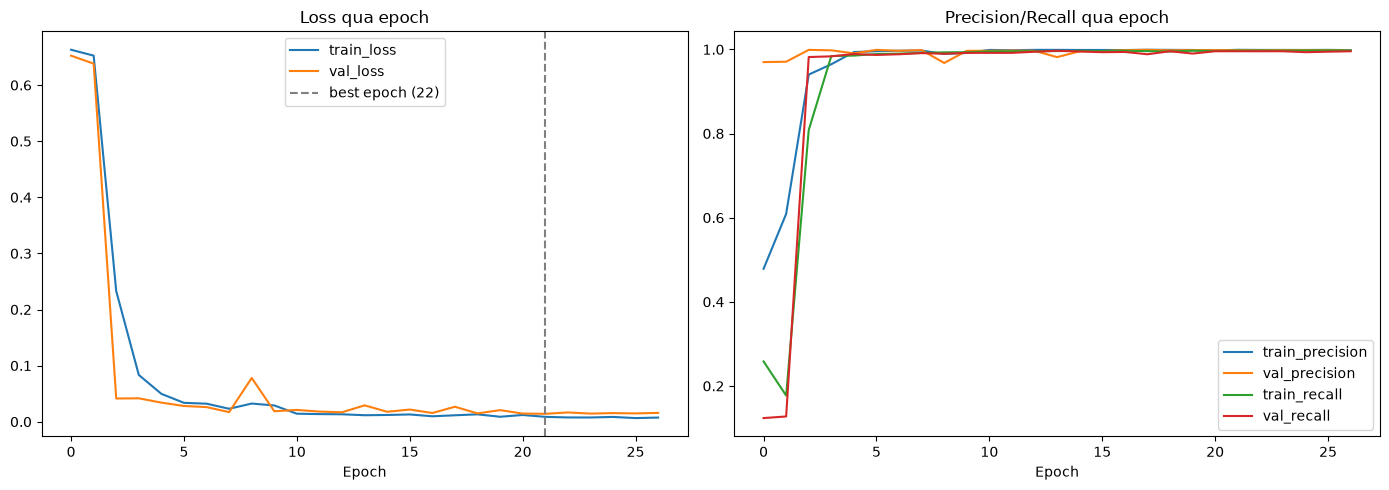

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time
import matplotlib.pyplot as plt

# B1: tính class_weight='balanced' bằng sklearn, giống phương pháp với Tầng 1
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print("class_weight:", class_weight_dict)
# Kỳ vọng: weight của lớp 1 (SQLi, thiểu số) > weight của lớp 0 (hợp lệ, đa số)

# B2: khởi tạo lại model mới, không dùng model đã huấn luyện thử ở Ngày 3
model_final = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.LSTM(units=64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_final.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

# B3: callback EarlyStopping (giữ nguyên patience=5 ở Tuần 3)
early_stop_final = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# B4: huấn luyện chính thức
start = time.time()
history = model_final.fit(
    train_sequences, y_train,
    validation_data=(val_sequences, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop_final],
    verbose=1
)
elapsed = time.time() - start

print(f"\nThời gian huấn luyện tổng: {elapsed/60:.2f} phút")
print(f"Số epoch thực tế đã chạy: {len(history.history['loss'])}")
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"Epoch có val_loss tốt nhất: {best_epoch}")
print(f"val_loss tốt nhất: {min(history.history['val_loss']):.4f}")

# B5: vẽ đồ thị loss/val_loss và precision/recall qua epoch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].axvline(best_epoch - 1, color='gray', linestyle='--', label=f'best epoch ({best_epoch})')
axes[0].set_title('Loss qua epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['precision'], label='train_precision')
axes[1].plot(history.history['val_precision'], label='val_precision')
axes[1].plot(history.history['recall'], label='train_recall')
axes[1].plot(history.history['val_recall'], label='val_recall')
axes[1].set_title('Precision/Recall qua epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/Week05/loss_precision_recall_curve.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# B1: dự đoán trên test_sequences bằng model_final (giữ trọng số epoch 22 nhờ restore_best_weights)
y_test = test_df["Label"].values  # xác nhận lại tên cột nếu khác

y_test_proba = model_final.predict(test_sequences, batch_size=64, verbose=1)
y_test_pred = (y_test_proba >= 0.5).astype(int).flatten()

#B2: tính Precision/Recall/F1/Confusion Matrix bằng sklearn
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("=== LSTM baseline (Tầng 2) — kết quả trên test.csv ===")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print(f"\nFN (SQLi bị bỏ sót): {cm[1][0]}")
print(f"FP (hợp lệ bị gắn cờ sai): {cm[0][1]}")

print("\n" + classification_report(y_test, y_test_pred, target_names=["Legitimate", "SQLi"]))

# B3: bảng so sánh 3 mô hình (và so sánh RF, SVM đã có từ Tuần 4)
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "LSTM baseline"],
    "Precision": [None, None, precision], 
    "Recall": [None, None, recall],
    "F1-score": [0.9958, 0.9938, f1], 
    "FN": [14, 22, cm[1][0]]
})
print("\n=== Bảng so sánh 3 mô hình trên cùng test.csv ===")
print(comparison.to_string(index=False))

97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step
=== LSTM baseline (Tầng 2) — kết quả trên test.csv ===
Precision: 0.9987
Recall:    0.9930
F1-score:  0.9958

Confusion Matrix:
[[3902    3]
 [  16 2260]]

FN (SQLi bị bỏ sót): 16
FP (hợp lệ bị gắn cờ sai): 3

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      3905
        SQLi       1.00      0.99      1.00      2276

    accuracy                           1.00      6181
   macro avg       1.00      1.00      1.00      6181
weighted avg       1.00      1.00      1.00      6181


=== Bảng so sánh 3 mô hình trên cùng test.csv ===
        Model  Precision  Recall  F1-score  FN
Random Forest        NaN     NaN  0.995800  14
          SVM        NaN     NaN  0.993800  22
LSTM baseline   0.998674 0.99297  0.995814  16


In [ ]:
import os
import json

os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

model_final.save("../models/tier2_lstm.h5")
print("Đã lưu models/tier2_lstm.h5")

class_weight_record = {
    "used": True,
    "method": "sklearn.utils.class_weight.compute_class_weight(balanced)",
    "values": {"0": 0.7913499239817556, "1": 1.3580747047514419},
    "decision_date": "Tuần 5, Ngày 3-4",
    "note": "PHẢI dùng lại đúng giá trị/phương pháp này cho Tầng 3 (LSTM+Attention) ở Tuần 6 để đảm bảo so sánh công bằng ở Tuần 7."
}
with open("../artifacts/tier2_class_weight_decision.json", "w", encoding="utf-8") as f:
    json.dump(class_weight_record, f, ensure_ascii=False, indent=2)
print("Đã lưu artifacts/tier2_class_weight_decision.json")

# Lưu toàn bộ training history phục vụ sau này
with open("../artifacts/tier2_training_history.json", "w", encoding="utf-8") as f:
    json.dump(history.history, f, indent=2)
print("Đã lưu artifacts/tier2_training_history.json")

# Lưu bảng kết quả test.csv của cả 3 mô hình để dùng lại ở Tuần 7
final_comparison = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "LSTM baseline"],
    "Precision": [0.9978, 0.9973, 0.9987],
    "Recall": [0.9938, 0.9903, 0.9930],
    "F1-score": [0.995818, 0.993826, 0.995814],
    "TN": [3900, 3899, 3902],
    "FP": [5, 6, 3],
    "FN": [14, 22, 16],
    "TP": [2262, 2254, 2260]
})
final_comparison.to_csv("../docs/Week05/model_comparison_tier1_tier2.csv", index=False)
print("Đã lưu docs/Week05/model_comparison_tier1_tier2.csv")

Đã lưu models/tier2_lstm.h5
Đã lưu artifacts/tier2_class_weight_decision.json
Đã lưu artifacts/tier2_training_history.json
Đã lưu docs/Week05/model_comparison_tier1_tier2.csv
